# Seed-based functional connectivity
---
Let's try to emulate the results from Biswal et al. (1995) \
"Functional Connectivity in the Motor Cortex of Resting Human Brain Using Echo-Planar MRI" \
https://pucrs-human-connectome-class-2014.github.io/papers/FunctionalConnectivityMotorCortexRestingBrain.pdf

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alanturin-g/Computational_Neuroscience_UNITO_2026/blob/main/Borriero_2_seed_based_functional_connectivity.ipynb)

In [ ]:
from google.colab import auth; auth.authenticate_user()
from google.colab import drive; drive.mount('/content/drive')

# Import

In [1]:
# Install the required libraries
! pip install nibabel nilearn nitime statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 5.6 MB/s eta 0:00:02
   -- ------------------------------------- 0.8/11.3 MB 3.4 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.3 MB 1.9 MB/s eta 0:00:06
   ---- ----------------------------------- 1.3/11.3 MB 1.4 MB/s eta 0:00:08
   ---- ----------------------------------- 1.3/11.3 MB 1.4 MB/s eta 0:00:08
   ----- ---------------------------------- 1.6/11.3 MB 1.3 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/11.3 MB 1.2 MB/s eta 0:00:08
   ------ --------------------------------- 1.8/11.3 MB 1.2 MB/s eta 0:00:08
   ------- -------------------------------- 2.1/11.3 MB 1.1 MB/s eta 0:00:09
   ------- -------------------------------- 2.1/11.3 MB 1.1 MB/s eta 0:00:09
   -------- ------------------------------- 2.4/11.3 MB 952.0 kB/s eta 0:00:10
   -------- ------------------------------- 2.4/11.3 MB 952.0 kB/s eta 0:00:10
  

In [2]:
import nilearn as nil
import nibabel as nib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from nilearn import plotting, surface, datasets
from scipy.stats import pearsonr, spearmanr, ttest_ind
from tqdm import tqdm # For having progressbar during loops
from nitime.timeseries import TimeSeries
from nitime.analysis import FilterAnalyzer
from statsmodels.stats.multitest import multipletests

# Download some files

In [ ]:
# A wrapper method to download files

import os, subprocess, shlex
import os
import subprocess

def download_from_drive(file_keyword, base_folder="."):
    file_name, file_ID = files_dict[file_keyword]
    DEST_PATH = os.path.join(base_folder, file_name)
    if not os.path.exists(DEST_PATH):
        URL = f"https://drive.usercontent.google.com/download?id={file_ID}&confirm=t"
        cmd = ["wget", "-q", "--show-progress", "--progress=bar:force:noscroll",
            "--no-check-certificate", "-O", DEST_PATH, URL]
        ret = subprocess.call(cmd)  # shell=False by default
        if ret != 0:
            raise RuntimeError("Download failed. Check sharing settings or FILE_ID.")
        else:
            print("Downloaded " + file_name + "!")
    else:
        print(file_name + " already present:", DEST_PATH)   

In [ ]:
files_dict = {'glasser_labels' : ('glasser_labels.csv','12LumqrRkp1rUAJGg8h3tOIwWubhyyoqY'),
              'glasser_atlas':   ('glasser_atlas.nii.gz','1GeB5pi25SRnyit8s5siDUCFFmJfsB3Yw'),
              'schaefer_labels': ('schaefer_labels.csv', '1Lgh4X9hud2xXGxYEWADFxfMe81P_tTfS'),
              'schaefer_atlas':  ('schaefer_atlas.nii.gz', '1acSTf6m9TyJxm2ruTcwd9eC8PNGfG1PX'),
              'subj_01_rest':  ('subj_01_rest.nii.gz', '1XXhVrMymlaBE0ekbgbHoH8fVYteWFGIa'),
              'subj_03_rest':  ('subj_03_rest.nii.gz', '1RziRBrPUFemlHfjPMoeJX26CbHhqlKM4'),
              'subj_04_rest':  ('subj_04_rest.nii.gz', '10thmeWWgk31FaBk0Qi0n_rtOef5YVAjM'),
              'subj_05_rest':  ('subj_05_rest.nii.gz', '1-_ifL8yQWAoUiU7v7niz6O9YbVGyj4xn'),
              'subj_06_rest':  ('subj_06_rest.nii.gz', '1iE-5pfybf8imraDfJvP6A-XuXIyHVHQD'),
              'subj_01_sleep':  ('subj_01_sleep.nii.gz', '1zAU1sI9jS0wzGp_raNUemxUYPilLIZJH'),
              'subj_03_sleep':  ('subj_03_sleep.nii.gz', '1C9pPi7PwTcdg4Nfz1xVVCFToghRTxSQQ'),
              'subj_04_sleep':  ('subj_04_sleep.nii.gz', '1fn6xCluS7lEasPKgHafThwvhA11Mo0A5'),
              'subj_05_sleep':  ('subj_05_sleep.nii.gz', '1DkWrsAa3-jLtVggLIujtxNfqhgwezhea'),
              'subj_06_sleep':  ('subj_06_sleep.nii.gz', '1PvG2KQMF40QnmNs6Z5kMx8abKk_tBH3C'),
              'all_subj_mask':  ('all_subj_mask.nii.gz', '1azzh7yXC4uG8clHv4Zm7sBZgta0dTMDf')}

In [ ]:
for key in files_dict.keys():
  download_from_drive(key)

# Load an example  subject

In [38]:
main_path = '/content/'
main_path = '../content/'
file_name = 'subj_01_rest.nii.gz'

sub_ = nib.load(main_path+file_name) # Load the nii.gz file of the subject
sub_header = sub_.header # Subject's header
sub_affine = sub_.affine # Subject's affine
sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
print(sub.shape) # x*y*z*time

brain_mask = np.zeros((60, 72, 60))
brain_mask[np.where(sub.mean(axis=-1))!=0] =1
n_vox_brain_mask = int(np.sum(brain_mask))

(60, 72, 60, 286)


# Load the mask

In [39]:
main_path = '/content/'
main_path = '../content/'
file_name = 'all_subj_mask.nii.gz' 
mask_ = nib.load(main_path+file_name)
mask = mask_.get_fdata()
n_vox_mask = int(np.sum(mask))

# Load the atlas
In order to define regions of the brain, we need an atlas

In [40]:
main_path = '/content/'
main_path = '../content/'
file_name = 'glasser_atlas.nii.gz'
file_name_labels = 'glasser_labels.csv'
path = main_path+file_name
path_lab = main_path+file_name_labels

atlas_ = nib.load(path)
atlas = atlas_.get_fdata()
atlas_header = atlas_.header
atlas_affine = atlas_.affine
atlas_labels = pd.read_csv(path_lab, delimiter=',')
print(atlas.shape)

# Define a mask from the atlas
mask = np.zeros(atlas.shape)
mask[np.where(atlas!=0)]=1
n_vox_mask = int(np.sum(mask))

(60, 72, 60)


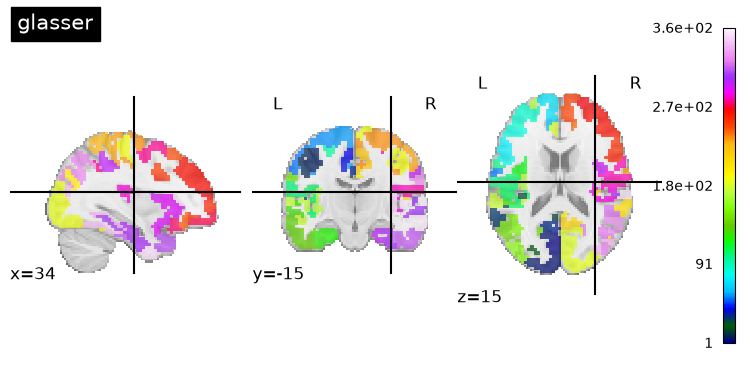

In [41]:
# Plot the atlas
plotting.plot_roi(atlas_, title='glasser', display_mode='ortho')

In [42]:
atlas_labels

,regionName,regionLongName,regionIdLabel,LR,region,Lobe,cortex,regionID,Cortex_ID,x-cog,y-cog,z-cog,volmm
0,V1_L,Primary_Visual_Cortex_L,1_L,L,V1,Occ,Primary_Visual,1,1,100.491589,41.138901,71.637040,6717
1,MST_L,Medial_Superior_Temporal_Area_L,2_L,L,MST,Occ,MT+_Complex_and_Neighboring_Visual_Areas,2,5,132.416667,58.901786,82.059524,336
2,V6_L,Sixth_Visual_Area_L,3_L,L,V6,Occ,Dorsal_Stream_Visual,3,3,104.543112,44.481665,103.916749,1009
3,V2_L,Second_Visual_Area_L,4_L,L,V2,Occ,Early_Visual,4,2,102.236656,44.064791,74.401125,6220
4,V3_L,Third_Visual_Area_L,5_L,L,V3,Occ,Early_Visual,5,2,107.926111,40.632159,76.961153,4994
...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,STSva_R,Area_STSv_anterior_R,376_R,R,STSva,Temp,Auditory_Association,376,11,32.924419,117.527907,54.337791,1720
356,TE1m_R,Area_TE1_Middle_R,377_R,R,TE1m,Temp,Lateral_Temporal,377,14,26.146605,102.236497,53.246528,2592
357,PI_R,Para-Insular_Area_R,378_R,R,PI,Temp,Insular_and_Frontal_Opercular,378,12,47.013363,123.157016,57.926503,898
358,a32pr_R,Area_anterior_32_prime_R,379_R,R,a32pr,Fr,Anterior_Cingulate_and_Medial_Prefrontal,379,19,81.723096,153.990326,102.516324,827


In [43]:
# Subdivision in cortices of the glasser atlas
# network_list = atlas_labels['ROI_network'].unique().tolist()
network_list = atlas_labels['cortex'].unique().tolist()
network_list

['Primary_Visual',
 'MT+_Complex_and_Neighboring_Visual_Areas',
 'Dorsal_Stream_Visual',
 'Early_Visual',
 'Ventral_Stream_Visual',
 'Somatosensory_and_Motor',
 'Premotor',
 'Posterior_Cingulate',
 'Early_Auditory',
 'Temporo-Parieto_Occipital_Junction',
 'Dorsolateral_Prefrontal',
 'Temporo-Parieto-Occipital_Junction',
 'Superior_Parietal',
 'Paracentral_Lobular_and_Mid_Cingulate',
 'Anterior_Cingulate_and_Medial_Prefrontal',
 'Orbital_and_Polar_Frontal',
 'Inferior_Frontal',
 'Posterior_Opercular',
 'Insular_and_Frontal_Opercular',
 'Auditory_Association',
 'Inferior_Parietal',
 'Medial_Temporal',
 'Lateral_Temporal']

# Exploring the functional connectivity of the motor cortex
Chose the motor cortex of one of the two emisphere as the seed area for the seed-based functional connectivity analysis

### Define the seed area

In [44]:
hemi = 'LH'
seed_areas = atlas_labels.loc[atlas_labels['regionLongName']=='Primary_Motor_Cortex_L']
seed_idxs = seed_areas['regionID'].values # Indexes of the seed areas
seed_areas

# seed_areas = seed_areas.loc[seed_areas['Hemisphere']==hemi]
# seed_idxs = seed_areas['ROI_label'].values # Indexes of the seed areas
# seed_areas

,regionName,regionLongName,regionIdLabel,LR,region,Lobe,cortex,regionID,Cortex_ID,x-cog,y-cog,z-cog,volmm
7,4_L,Primary_Motor_Cortex_L,8_L,L,4,Fr,Somatosensory_and_Motor,8,6,119.338359,105.485002,126.65561,6301


In [45]:
# Create a brain mask of our seed region
seeds_mask = np.zeros(atlas.shape)
for seed in seed_idxs:
    seeds_mask += (atlas==seed)

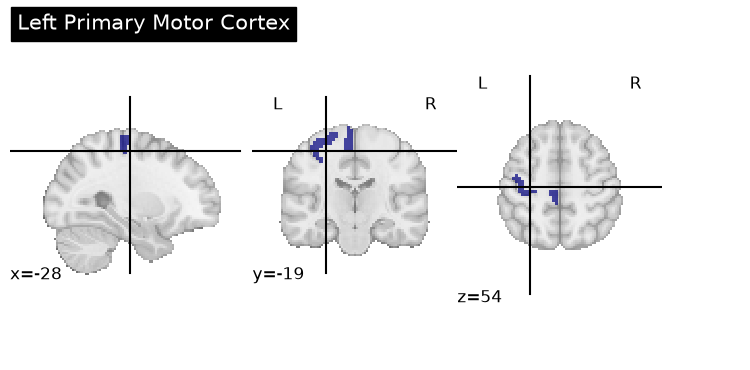

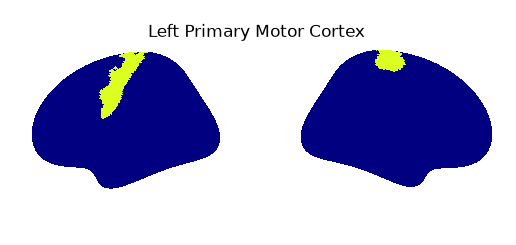

In [46]:
## Plot the seed region

# Plot over the volume of the brain
seeds_img = nib.Nifti1Image(seeds_mask.astype(np.int16), atlas_affine) # Create a new image for the selected region
plotting.plot_roi(seeds_img, display_mode='ortho', title='Left Primary Motor Cortex')
plotting.show()

# Plot over the surface of the brain ##
fsaverage = datasets.fetch_surf_fsaverage()
texture_left = surface.vol_to_surf(seeds_img, fsaverage.pial_left)
texture_left[np.where(texture_left!=0)] = 1

fig, axs = plt.subplots(1,2, subplot_kw={'projection': '3d'})
# left hemisphere
plotting.plot_surf_roi(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       colorbar=False, view='lateral',axes=axs[0])
plotting.plot_surf_roi(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       colorbar=False, view='medial', axes=axs[1])
fig.suptitle('Left Primary Motor Cortex', x=0.51, y=0.7)

plotting.show()

# Compute the whole brain functional connectivity map for the seed region

## At first, compute the average time series of the seed region

In [47]:
# Apply the seed's mask to the whole brain, then average the time series of the voxels within the seed, in order
# to obtain the time series off the whole seed
sub = sub
seed_voxels = sub[seeds_mask==1]
print(seed_voxels.shape)
seed_ts = seed_voxels.mean(axis=0)
print(seed_ts.shape)

(393, 286)
(286,)


We are assuming an isotropy of the signal inside the seed region...

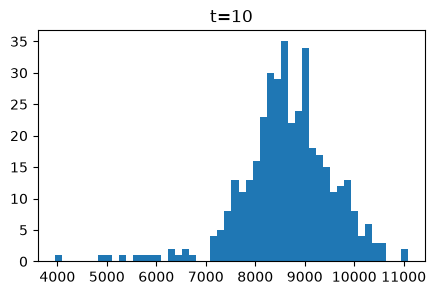

In [48]:
# Let's check the distribution of the activity values of the voxels inside the seed region
t = 10 # choose a time point
fig = plt.figure(figsize=(5,3))
plt.hist(seed_voxels[:,t], bins=50);
plt.title('t='+str(t));

Text(0.5, 1.0, "Average seed's time series")

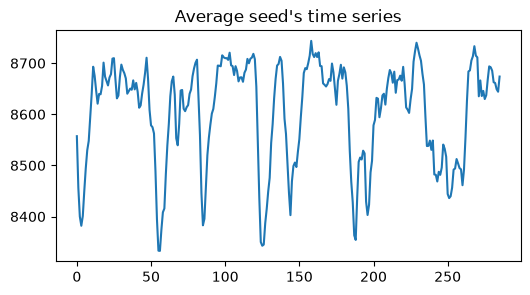

In [49]:
# Visualize the average time series of the seed region
fig = plt.figure(figsize=(6,3))
plt.plot(seed_ts);
plt.title("Average seed's time series")
# plt.xlim(0,20)

## Correlate the time series of the seed with all the other voxels of the brain

In [50]:
sub = sub
# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr
fcmap = np.zeros(mask.shape) # Initialize the functional connectivity map
fcmap_p = np.zeros(mask.shape) # p-values related the correlation measure
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask

# Loop over all the voxel of the brain
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    corr = corr_measure(seed_ts, voxel_ts)
    fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
    fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]


  0%|          | 0/35216 [00:00<?, ?it/s]

 43%|████▎     | 15041/35216 [00:04<00:05, 4018.00it/s]C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\645634196.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = corr_measure(seed_ts, voxel_ts)
100%|██████████| 35216/35216 [00:08<00:00, 3976.20it/s]


c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


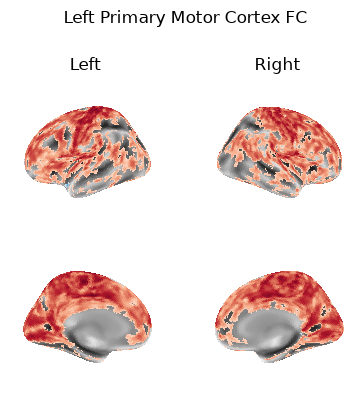

In [51]:
# Plot the FC maps
# threshold the Fc maps with the pvalues 
fcmap_thresholded = np.copy(fcmap)
fcmap_thresholded[np.where(fcmap_p>0.001/n_vox_mask)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(fcmap_thresholded, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.2 # Threshold for the brain plots

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(4,4))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                       title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1])
fig.suptitle('Left Primary Motor Cortex FC', x=0.51, y=1)
plt.tight_layout()
plotting.show()

## Try to clean the signal before the fc analysis

100%|██████████| 5/5 [00:00<00:00, 63.20it/s]


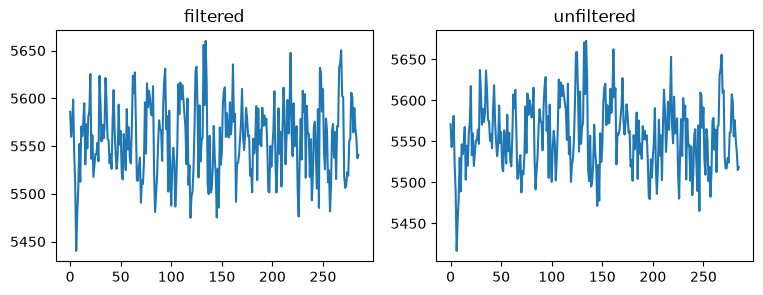

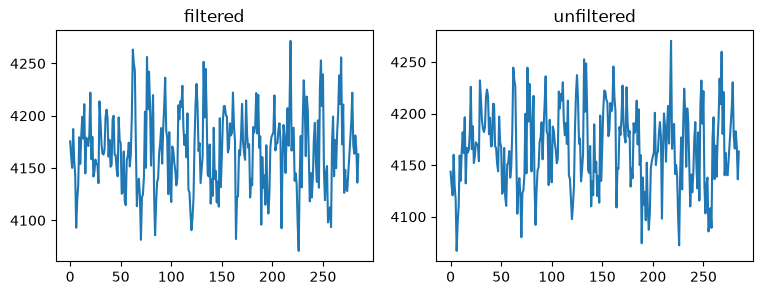

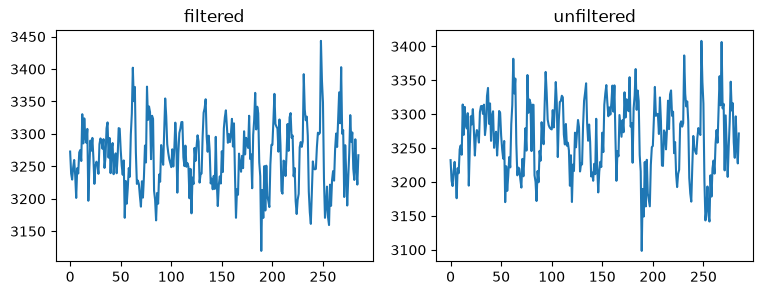

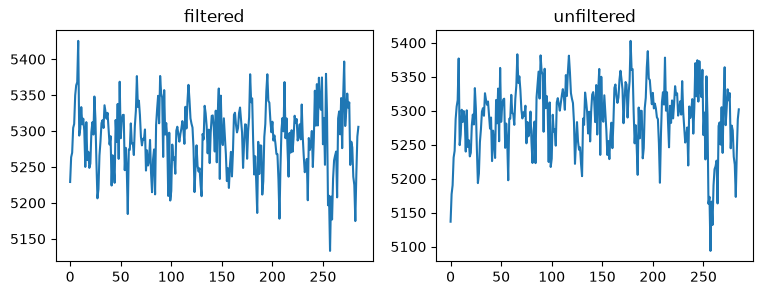

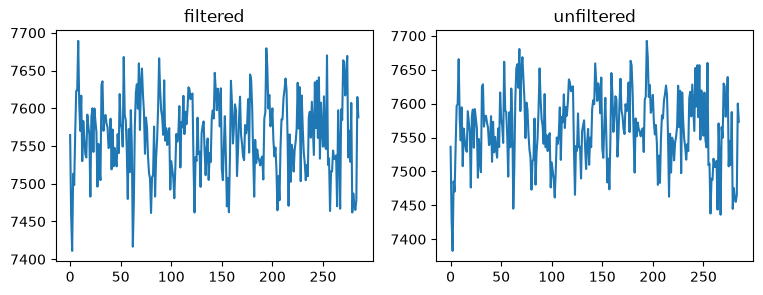

In [52]:
# An example of filtering with a bandpass filter
sub_filtered = np.copy(sub)
TR = sub_.header.get_zooms()[3]
for v in tqdm(range(15,20)):
    voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    T = TimeSeries(voxel_ts.T, sampling_interval=TR)
    F = FilterAnalyzer(T, ub=0.25, lb=0.01) #0.08, 0.008
    tmp_TC_filt = F.filtered_boxcar.data
    tmp_TC_filt = tmp_TC_filt.T
    sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt
    fig,axs = plt.subplots(1,2, figsize=(9,3))
    axs[0].plot(tmp_TC_filt, alpha=1)
    axs[0].set_title('filtered')
    axs[1].plot(voxel_ts, alpha=1)
    axs[1].set_title('unfiltered')


In [54]:
# Filter an entire subject
sub_filtered = np.copy(sub)
TR = sub_.header.get_zooms()[3]
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    T = TimeSeries(voxel_ts.T, sampling_interval=TR)
    F = FilterAnalyzer(T, ub=0.25, lb=0.01) #0.08, 0.008
    tmp_TC_filt = F.filtered_boxcar.data
    tmp_TC_filt = tmp_TC_filt.T
    sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt
#     plt.plot(tmp_TC_filt, label='filtered', alpha=0.75)
#     plt.plot(voxel_ts, label='original', alpha=0.75)
#     plt.legend()

100%|██████████| 35216/35216 [00:05<00:00, 6545.31it/s]


In [55]:
# Now perform the analysis with the filtered subject

# Extract the time series of the seed region
seed_voxels = sub_filtered[seeds_mask==1]
seed_ts = seed_voxels.mean(axis=0)

# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr

fcmap = np.zeros(mask.shape) # Initialize the functional connectivity map
fcmap_p = np.zeros(mask.shape) # p-values related the correlation measure
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask

## Correlation ##
# Loop over all the voxel of the brain
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    corr = corr_measure(seed_ts, voxel_ts)
    fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
    fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]

  0%|          | 0/35216 [00:00<?, ?it/s]

 43%|████▎     | 15067/35216 [00:04<00:06, 3299.16it/s]C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\1464612214.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = corr_measure(seed_ts, voxel_ts)
100%|██████████| 35216/35216 [00:16<00:00, 2087.30it/s]


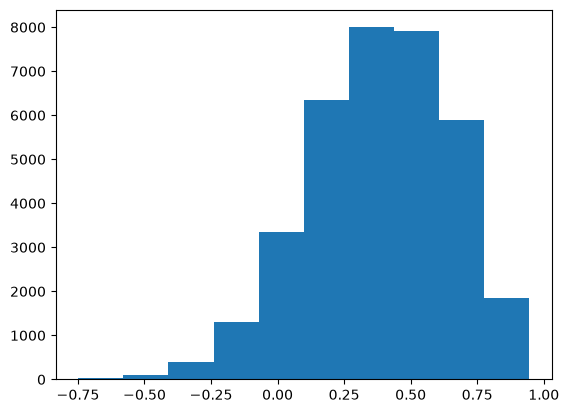

In [56]:
plt.hist(fcmap[fcmap!=0]);

c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)


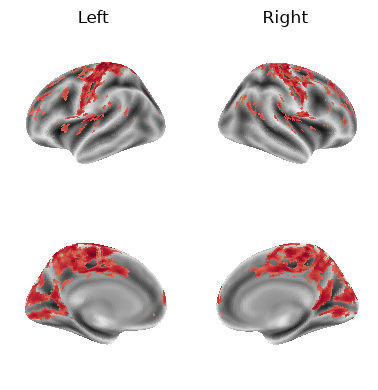

In [57]:
# Plot the FC map
# threshold the FC map with the pvalues 
fcmap_thresholded = np.copy(fcmap)
fcmap_thresholded[np.where(fcmap_p>0.001/n_vox_mask)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(fcmap_thresholded, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.5 # Threshold for the brain plots

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(4,4))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                       title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1])
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0])
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1])
plt.tight_layout()
plotting.show()

# Compute the functional connectivity for many subjects

In [63]:
# sub_list = ['01','03','04','05','06','07','08','09','10','11','12','13','14','15','16','17','18','19','20','22','23','24','25','26','27','28','29','30','31','32','33']
# sub_list = ['01','03','04','05','06','07','08','09','10','11']
sub_list = ['01','03','04','05','06']

# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask


fcmap_allsub = np.zeros(mask.shape)[np.newaxis,:,:,:]
fcmap_p_allsub = np.zeros(mask.shape)[np.newaxis,:,:,:]

# Loop over the subjects
main_path = '/content/'
main_path = '../content/'

for sub_i,sub in enumerate(sub_list): # Loop over the subjects    
    print(sub)
    file_name = 'subj_'+sub+'_rest.nii.gz'
    sub_ = nib.load(main_path+file_name) # Load the nii.gz file of the subject
    sub_header = sub_.header # Subject's header
    sub_affine = sub_.affine # Subject's affine
    sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
    
    # Filter the signal
    sub_filtered = np.copy(sub)
    TR = sub_.header.get_zooms()[3]
    print('Filtering the signal...')
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        T = TimeSeries(voxel_ts.T, sampling_interval=TR)
        F = FilterAnalyzer(T, ub=0.25, lb=0.01) # or 0.08, 0.008
        tmp_TC_filt = F.filtered_boxcar.data
        tmp_TC_filt = tmp_TC_filt.T
        sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

    # Compute the average time series of the seed region
    seed_voxels = sub_filtered[seeds_mask==1]
    seed_ts = seed_voxels.mean(axis=0)

    fcmap = np.zeros(mask.shape) # Initialize the functional connectivity map
    fcmap_p = np.zeros(mask.shape) # p-values related the correlation measure

    # Loop over all the voxel of the brain
    print('Computing the correlation...')
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        corr = corr_measure(seed_ts, voxel_ts)
        fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
        fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]
    
    fcmap_allsub = np.concatenate((fcmap_allsub, fcmap[np.newaxis,:,:,:]))
    fcmap_p_allsub = np.concatenate((fcmap_p_allsub, fcmap_p[np.newaxis,:,:,:]))

01
Filtering the signal...


100%|██████████| 35216/35216 [00:13<00:00, 2574.76it/s]


Computing the correlation...


 44%|████▎     | 15386/35216 [00:08<00:18, 1047.27it/s]C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\45434281.py:49: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = corr_measure(seed_ts, voxel_ts)
100%|██████████| 35216/35216 [00:28<00:00, 1216.65it/s]


03
Filtering the signal...


...

100%|██████████| 35216/35216 [00:08<00:00, 3981.17it/s]


06
Filtering the signal...


100%|██████████| 35216/35216 [00:05<00:00, 6184.29it/s]


Computing the correlation...


100%|██████████| 35216/35216 [00:08<00:00, 3915.40it/s]


c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\2707968611.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


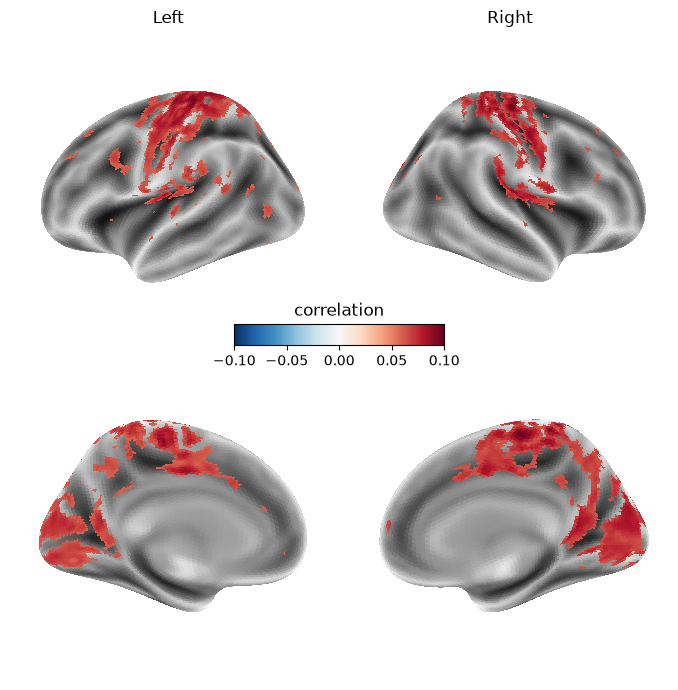

In [68]:
# Plot the FC map
cmap='RdBu_r'

av_fcmap_allsub = fcmap_allsub.mean(axis=0)
av_fcmap_p_allsub = fcmap_p_allsub.mean(axis=0)
# # threshold the Fc maps with the pvalues 
# fcmap_thresholded = np.copy(av_fcmap_allsub)
# fcmap_thresholded[np.where(av_fcmap_p_allsub>0.05)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(av_fcmap_allsub, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.4 # Threshold for the brain plots
vmin = av_fcmap_allsub.min()
vmax = av_fcmap_allsub.max()

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(7,7))
### Qui facciamo un plot più carino ###
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0],
                            vmin=vmin, vmax=vmax, cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1],
                            vmin=vmin, vmax=vmax, cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0],
                            vmin=vmin, vmax=vmax, cmap=cmap)
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1],
                                            vmin=vmin, vmax=vmax, cmap=cmap)

# Create horizontal colorbar below the two brains
cax = fig.add_axes([0.35, 0.5, 0.3, 0.03])  # [left, bottom, width, height]
cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap=cmap),
    cax=cax,
    orientation='horizontal')
cax.set_title('correlation')

plt.tight_layout()
plotting.show()

# Let's try to find the Default Mode Network

## Define the seed areas
We choose the medial frontal cortex, one of the main regions of the default mode network

In [92]:
# seed_areas = atlas_labels.loc[atlas_labels['cortex']=='Somatosensory_and_Motor']
# seed_areas = atlas_labels.loc[atlas_labels['regionLongName']=='PreCuneus_Visual_Area_L']
# seed_areas_names = ['Area_10r_L','Area_10v_L', 'Area_9_Middle_L']
seed_areas_names =  ['PreCuneus_Visual_Area_L']
seed_idxs = []
for s in seed_areas_names:
    seed_areas = atlas_labels.loc[atlas_labels['regionLongName']==s]
    seed_idx = seed_areas['regionID'].values # Indexes of the seed areas
    seed_idxs.append(seed_idx[0])

In [93]:
# Make the brain mask of the seed
seeds_mask = np.zeros(atlas.shape)
for seed in seed_idxs:
    seeds_mask += (atlas==seed)

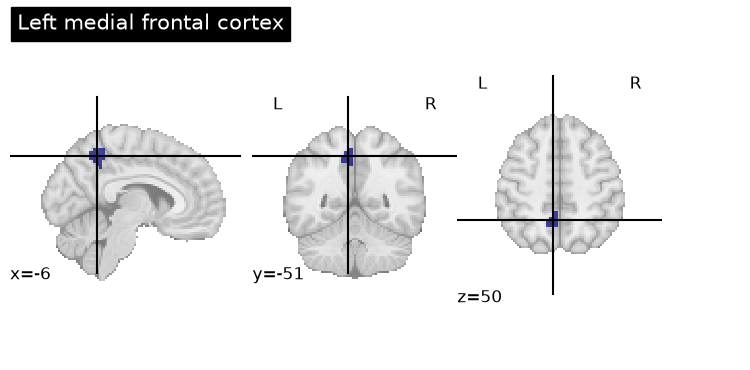

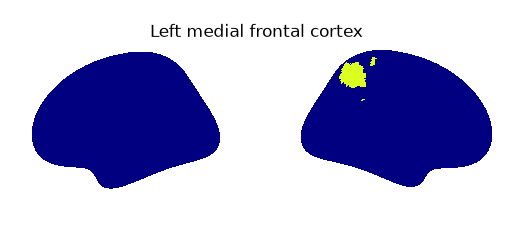

In [94]:
### Plot the seed area ###
## Plot on the volume of the brain

# Create a new image for the selected region
seeds_img = nib.Nifti1Image(seeds_mask.astype(np.int16), atlas_affine)
# Plot the selected region
plotting.plot_roi(seeds_img, display_mode='ortho', title='Left medial frontal cortex')
plotting.show()

# Plot over the surface of the brain ##
fsaverage = datasets.fetch_surf_fsaverage()
texture_left = surface.vol_to_surf(seeds_img, fsaverage.pial_left)
texture_left[np.where(texture_left!=0)] = 1

fig, axs = plt.subplots(1,2, subplot_kw={'projection': '3d'})
# left hemisphere
plotting.plot_surf_roi(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       colorbar=False, view='lateral',axes=axs[0])
plotting.plot_surf_roi(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                       colorbar=False, view='medial', axes=axs[1])
fig.suptitle('Left medial frontal cortex', x=0.51, y=0.7);

In [96]:
### Signal filtering ###
sub_filtered = np.copy(sub)
TR = sub_.header.get_zooms()[3]
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    T = TimeSeries(voxel_ts.T, sampling_interval=TR)
    F = FilterAnalyzer(T, ub=0.25, lb=0.01) #or 0.08, 0.008
    tmp_TC_filt = F.filtered_boxcar.data
    tmp_TC_filt = tmp_TC_filt.T
    sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

100%|██████████| 35216/35216 [00:11<00:00, 3150.34it/s]


In [97]:
# Extract the time series of the seed region
seed_voxels = sub_filtered[seeds_mask==1]
seed_ts = seed_voxels.mean(axis=0)

# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr

# Initialize stuff
fcmap = np.zeros(mask.shape) # Initialize the functional connectivity map
fcmap_p = np.zeros(mask.shape) # p-values related the correlation measure
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask

## Correlation ##
# Loop over all the voxel of the brain
for v in tqdm(range(n_vox_mask)):
    voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
    corr = corr_measure(seed_ts, voxel_ts)
    fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
    fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]

 41%|████      | 14302/35216 [00:06<00:08, 2353.76it/s]C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\2167568138.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = corr_measure(seed_ts, voxel_ts)
100%|██████████| 35216/35216 [00:15<00:00, 2238.57it/s]


c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\2319770924.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


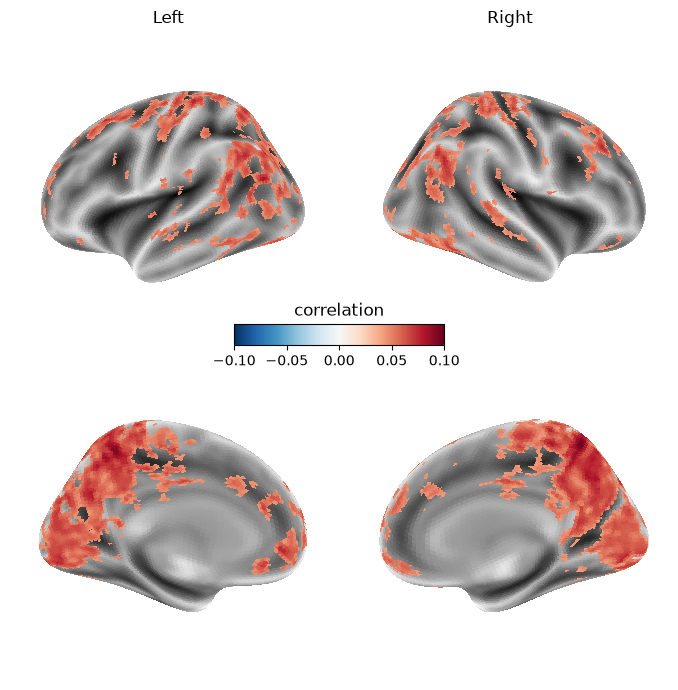

In [98]:
# threshold the Fc maps with the pvalues 
cmap='RdBu_r'

fcmap_thresholded = np.copy(fcmap)
fcmap_thresholded[np.where(fcmap_p>0.01/n_vox_mask)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(fcmap_thresholded, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.35 # Threshold for the brain plots
vmin = fcmap_thresholded.min()
vmax = fcmap_thresholded.max()

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(7,7))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0],
                            vmin=vmin, vmax=vmax, cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1],
                            vmin=vmin, vmax=vmax, cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0],
                            vmin=vmin, vmax=vmax, cmap=cmap)

plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1],
                            vmin=vmin, vmax=vmax, cmap=cmap)


# Create horizontal colorbar below the two brains
cax = fig.add_axes([0.35, 0.5, 0.3, 0.03])  # [left, bottom, width, height]
cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap=cmap),
    cax=cax,
    orientation='horizontal')
cax.set_title('correlation')

plt.tight_layout()
plotting.show()

## Let's do the analysis for all the subjects

In [99]:
main_path='/content/' # Path to the folder with the subjects
main_path='../content/' # Path to the folder with the subjects

sub_list = ['01','03','04','05','06']

# At first, choose the coorrelation measure
corr_measure = pearsonr
# corr_measure = spearmanr
mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask


fcmap_allsub = np.zeros(mask.shape)[np.newaxis,:,:,:]
fcmap_p_allsub = np.zeros(mask.shape)[np.newaxis,:,:,:]

# Loop over the subjects
for sub in sub_list:
    sub_file = 'subj_'+sub+'_rest.nii.gz'
    print(sub_file)
    sub_ = nib.load(main_path+sub_file) # Load the nii.gz file of the subject
    sub_header = sub_.header # Subject's header
    sub_affine = sub_.affine # Subject's affine
    sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
    
    # Filter the signal
    sub_filtered = np.copy(sub)
    TR = sub_.header.get_zooms()[3]
    print('Filtering the signal...')
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        T = TimeSeries(voxel_ts.T, sampling_interval=TR)
        F = FilterAnalyzer(T, ub=0.25, lb=0.01) # or 0.08, 0.008
        tmp_TC_filt = F.filtered_boxcar.data
        tmp_TC_filt = tmp_TC_filt.T
        sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

    # Compute the average time series of the seed region
    seed_voxels = sub_filtered[seeds_mask==1]
    seed_ts = seed_voxels.mean(axis=0)

    fcmap = np.zeros(mask.shape) # Initialize the functional connectivity map
    fcmap_p = np.zeros(mask.shape) # p-values related the correlation measure

    # Loop over all the voxel of the brain
    print('Computing the correlation...')
    for v in tqdm(range(n_vox_mask)):
        voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
        corr = corr_measure(seed_ts, voxel_ts)
        fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
        fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]
    
    fcmap_allsub = np.concatenate((fcmap_allsub, fcmap[np.newaxis,:,:,:]))
    fcmap_p_allsub = np.concatenate((fcmap_p_allsub, fcmap_p[np.newaxis,:,:,:]))

subj_01_rest.nii.gz
Filtering the signal...


100%|██████████| 35216/35216 [00:08<00:00, 3976.14it/s]


Computing the correlation...


 44%|████▎     | 15377/35216 [00:21<00:29, 678.33it/s]C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\454152882.py:47: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = corr_measure(seed_ts, voxel_ts)
100%|██████████| 35216/35216 [00:53<00:00, 658.45it/s]


subj_03_rest.nii.gz
Filtering the signal...


...

100%|██████████| 35216/35216 [00:17<00:00, 1984.60it/s]


subj_06_rest.nii.gz
Filtering the signal...


100%|██████████| 35216/35216 [00:08<00:00, 4098.70it/s]


Computing the correlation...


100%|██████████| 35216/35216 [00:17<00:00, 2060.11it/s]


c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
c:\Users\alebo\miniconda3\Lib\site-packages\nilearn\surface\surface.py:1242: RuntimeWarning: Mean of empty slice
  texture = np.nanmean(all_samples, axis=2)
C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\2544767046.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


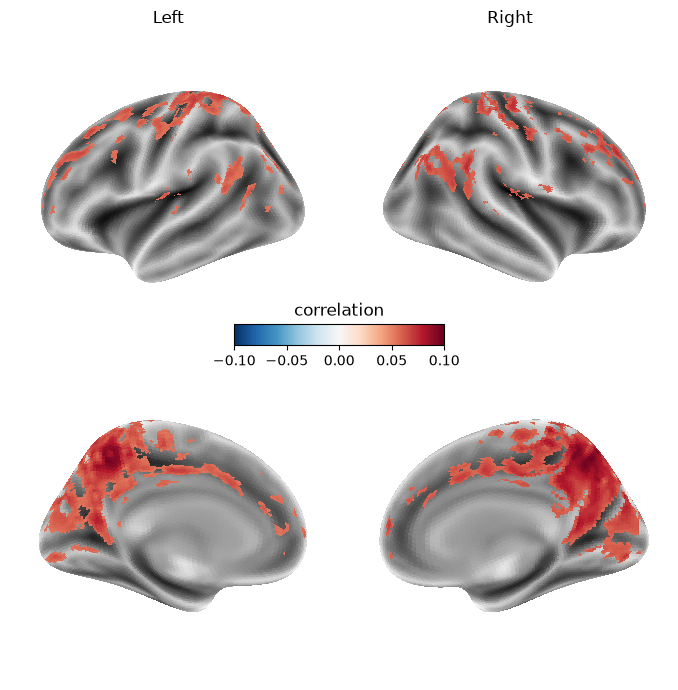

In [101]:
cmap = cmap='RdBu_r'

av_fcmap_allsub = fcmap_allsub.mean(axis=0)
av_fcmap_p_allsub = fcmap_p_allsub.mean(axis=0)
# # threshold the Fc maps with the pvalues 
# fcmap_thresholded = np.copy(av_fcmap_allsub)
# fcmap_thresholded[np.where(av_fcmap_p_allsub>0.05)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(av_fcmap_allsub, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.35 # Threshold for the brain plots
vmin = av_fcmap_allsub.min()
vmax = av_fcmap_allsub.max()

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(7,7))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0],
                            vmin=vmin, vmax=vmax, cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1],
                            vmin=vmin, vmax=vmax, cmap=cmap)
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0],
                            vmin=vmin, vmax=vmax, cmap=cmap)

# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1],
                            vmin=vmin, vmax=vmax, cmap=cmap)


# Create horizontal colorbar below the two brains
cax = fig.add_axes([0.35, 0.5, 0.3, 0.03])  # [left, bottom, width, height]
cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap=cmap),
    cax=cax,
    orientation='horizontal')
cax.set_title('correlation')

plt.tight_layout()
plotting.show()

# Compare the functional connectivity between rest and sleep

In [102]:
# seed_areas = atlas_labels.loc[atlas_labels['cortex']=='Somatosensory_and_Motor']
# seed_areas = atlas_labels.loc[atlas_labels['regionLongName']=='PreCuneus_Visual_Area_L']
# seed_areas_names = ['Area_10r_L','Area_10v_L', 'Area_9_Middle_L']
seed_areas_names = ['PreCuneus_Visual_Area_L']
seed_idxs = []
for s in seed_areas_names:
    seed_areas = atlas_labels.loc[atlas_labels['regionLongName']==s]
    seed_idx = seed_areas['regionID'].values # Indexes of the seed areas
    seed_idxs.append(seed_idx[0])

# Make the brain mask of the seed
seeds_mask = np.zeros(atlas.shape)
for seed in seed_idxs:
    seeds_mask += (atlas==seed)

In [108]:
### Compute the FC maps for the two conditions ###

main_path='/content/' # Path to the folder with the subjects
main_path='../content/' # Path to the folder with the subjects

sub_list = ['01','03','04','05','06']
fc_all_cond = [] # where to store the fc of all the subjects of the two groups
for c, cond in enumerate(['rest','sleep']):

    # At first, choose the coorrelation measure
    corr_measure = pearsonr
    # corr_measure = spearmanr
    mask_cord = np.where(mask==1) # Coordinates of all the voxel within the brain mask


    fcmap_allsub = np.zeros(mask.shape)[np.newaxis,:,:,:]
    fcmap_p_allsub = np.zeros(mask.shape)[np.newaxis,:,:,:]

    # Loop over the subjects
    for sub in sub_list:
        print(sub)
        if cond=='rest':
            sub_file = 'subj_'+sub+'_rest.nii.gz'
        else: # Sleep
            sub_file = 'subj_'+sub+'_sleep.nii.gz'
        sub_ = nib.load(main_path+sub_file) # Load the nii.gz file of the subject
        sub_header = sub_.header # Subject's header
        sub_affine = sub_.affine # Subject's affine
        sub = sub_.get_fdata() # Get the numpy version of the nii.gz file
        
        # Filter the signal
        sub_filtered = np.copy(sub)
        TR = sub_.header.get_zooms()[3]
        print('Filtering the signal...')
        for v in tqdm(range(n_vox_mask)):
            voxel_ts = sub[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
            T = TimeSeries(voxel_ts.T, sampling_interval=TR)
            F = FilterAnalyzer(T, ub=0.08, lb=0.008) #0.08, 0.008
            tmp_TC_filt = F.filtered_boxcar.data
            tmp_TC_filt = tmp_TC_filt.T
            sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] = tmp_TC_filt

        # Compute the average time series of the seed region
        seed_voxels = sub_filtered[seeds_mask==1]
        seed_ts = seed_voxels.mean(axis=0)

        fcmap = np.zeros(mask.shape) # Initialize the functional connectivity map
        fcmap_p = np.zeros(mask.shape) # p-values related the correlation measure

        # Loop over all the voxel of the brain
        print('Computing the correlation...')
        for v in tqdm(range(n_vox_mask)):
            voxel_ts = sub_filtered[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v], :] # time series of the single voxel
            corr = corr_measure(seed_ts, voxel_ts)
            fcmap[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[0]
            fcmap_p[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = corr[1]
        
        fcmap_allsub = np.concatenate((fcmap_allsub, fcmap[np.newaxis,:,:,:]))
        fcmap_p_allsub = np.concatenate((fcmap_p_allsub, fcmap_p[np.newaxis,:,:,:]))
    fc_all_cond.append(fcmap_allsub)

01
Filtering the signal...


100%|██████████| 35216/35216 [00:09<00:00, 3821.36it/s]


Computing the correlation...


 44%|████▎     | 15356/35216 [00:08<00:10, 1960.54it/s]C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\3133825897.py:54: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = corr_measure(seed_ts, voxel_ts)
100%|██████████| 35216/35216 [00:18<00:00, 1866.70it/s]


03
Filtering the signal...


...

100%|██████████| 35216/35216 [00:19<00:00, 1851.23it/s]


06
Filtering the signal...


100%|██████████| 35216/35216 [00:09<00:00, 3523.11it/s]


Computing the correlation...


100%|██████████| 35216/35216 [00:18<00:00, 1944.78it/s]


In [109]:
p_thresh = 0.05
corrected = False

cmap='coolwarm'    

t_brain = np.zeros(mask.shape)
p_brain_corr = np.zeros(mask.shape)
p_brain_uncorr = np.zeros(mask.shape)
for v in tqdm(range(n_vox_mask)): # Loop over all the voxels within the mask
    c1_voxel = fc_all_cond[0][:, mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] # time series of the single voxel
    c2_voxel = fc_all_cond[1][:, mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]]

    t, p = ttest_ind(c1_voxel, c2_voxel)
    t_brain[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = t
    if np.isnan(p):
        p_brain_uncorr[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = 1
    else:
        p_brain_uncorr[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = p
        

# Correction for multiple comparison
p_vals = p_brain_uncorr[mask==1]
p_vals_corr = multipletests(p_vals, alpha=0.05, method='fdr_bh')[1]
for v in tqdm(range(n_vox_mask)): # Loop over all the voxels within the mask
    p_brain_corr[mask_cord[0][v], mask_cord[1][v], mask_cord[2][v]] = p_vals_corr[v]


# Plot
if corrected:
    p_brain = np.copy(p_brain_corr) # Pre-Post average
else:
    p_brain = np.copy(p_brain_uncorr) # Pre-Post average

t_brain = np.copy(t_brain) 
p_brain[np.isnan(p_brain)]=0
t_brain[np.isnan(t_brain)]=0
t_brain[p_brain>p_thresh]=0

100%|██████████| 35216/35216 [00:00<00:00, 1536897.52it/s]


C:\Users\alebo\AppData\Local\Temp\ipykernel_12548\4179772210.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


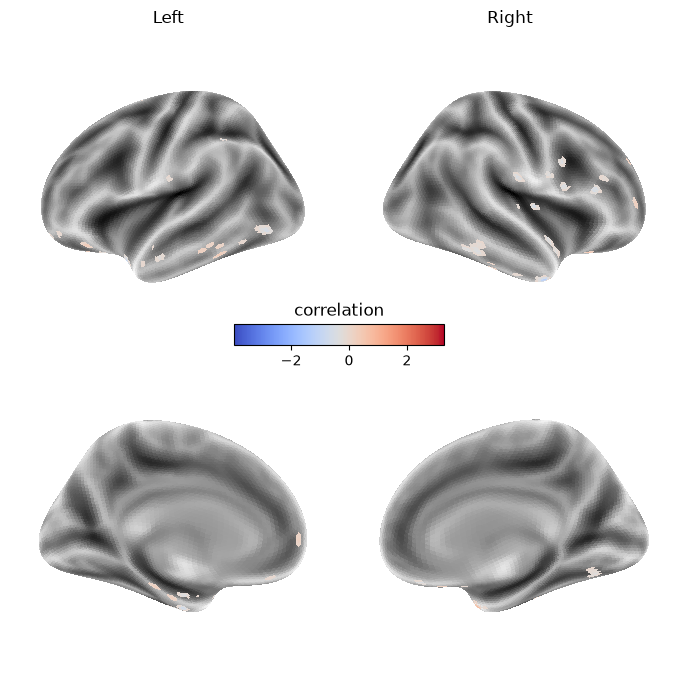

In [112]:
# threshold the Fc maps with the pvalues 
fcmap_thresholded = np.copy(t_brain)
# fcmap_thresholded[np.where(fcmap_p>0.01/n_vox_mask)] = 0

fsaverage = datasets.fetch_surf_fsaverage()
fcmap_img = nib.Nifti1Image(fcmap_thresholded, sub_affine)
texture_left = surface.vol_to_surf(fcmap_img, fsaverage.pial_left)
texture_right = surface.vol_to_surf(fcmap_img, fsaverage.pial_right)

thresh = 0.05 # Threshold for the brain plots
vmin = fcmap_thresholded.min()
vmax = fcmap_thresholded.max()

fig, axs = plt.subplots(2,2, subplot_kw={'projection': '3d'}, figsize=(7,7))
# Left hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            title='Left', view='lateral',colorbar=False, threshold=thresh, axes=axs[0][0],
                            vmin=vmin, vmax=vmax, cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            title='Right', view='lateral', colorbar=False, threshold=thresh, axes=axs[0][1],
                            vmin=vmin, vmax=vmax, cmap=cmap)
# Right hemisphere
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, bg_map=fsaverage.sulc_left,hemi='left',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][0],
                            vmin=vmin, vmax=vmax, cmap=cmap)
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, bg_map=fsaverage.sulc_right,hemi='right',
                            view='medial', colorbar=False, threshold=thresh, axes=axs[1][1],
                            vmin=vmin, vmax=vmax, cmap=cmap)

# Create horizontal colorbar below the two brains
cax = fig.add_axes([0.35, 0.5, 0.3, 0.03])  # [left, bottom, width, height]
cb = fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(vmin, vmax), cmap=cmap),
    cax=cax,
    orientation='horizontal')
cax.set_title('correlation')

plt.tight_layout()
plotting.show()